# Schritt 1: Titel & Zielsetzung
# CNN für CIFAR-10: Dropout und BatchNormalization

In diesem Notebook untersuchen wir ein Convolutional Neural Network (CNN) für den CIFAR-10-Datensatz.

## Ziel

Wir analysieren gezielt den Einfluss von:

- Dropout (Regularisierung)
- BatchNormalization (stabileres Training)

## Leitfragen

- Wie verändert Dropout die Lernkurven?
- Wie beeinflusst BatchNormalization die Konvergenzgeschwindigkeit?
- Welche Klassen werden am häufigsten verwechselt?

# Schritt 2: GPU-Hinweis (wichtig für CIFAR-10)
## Hinweis zur Laufzeit (Google Colab)

Für dieses Notebook wird ein GPU-Beschleuniger empfohlen:

Runtime → Hardwarebeschleuniger → GPU

Ohne GPU kann das Training deutlich länger dauern.

# Schritt 3: Bibliotheken

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Schritt 4: CIFAR-10 laden
## CIFAR-10-Datensatz

- 60.000 Bilder (32×32, RGB)
- 10 Klassen (z. B. Flugzeug, Auto, Katze, Hund)
- deutlich komplexer als Fashion-MNIST

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Trainingsdaten:", X_train_full.shape)
print("Testdaten:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainingsdaten: (50000, 32, 32, 3)
Testdaten: (10000, 32, 32, 3)


# Schritt 5: Klassennamen

In [3]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Schritt 6: Bilder anzeigen

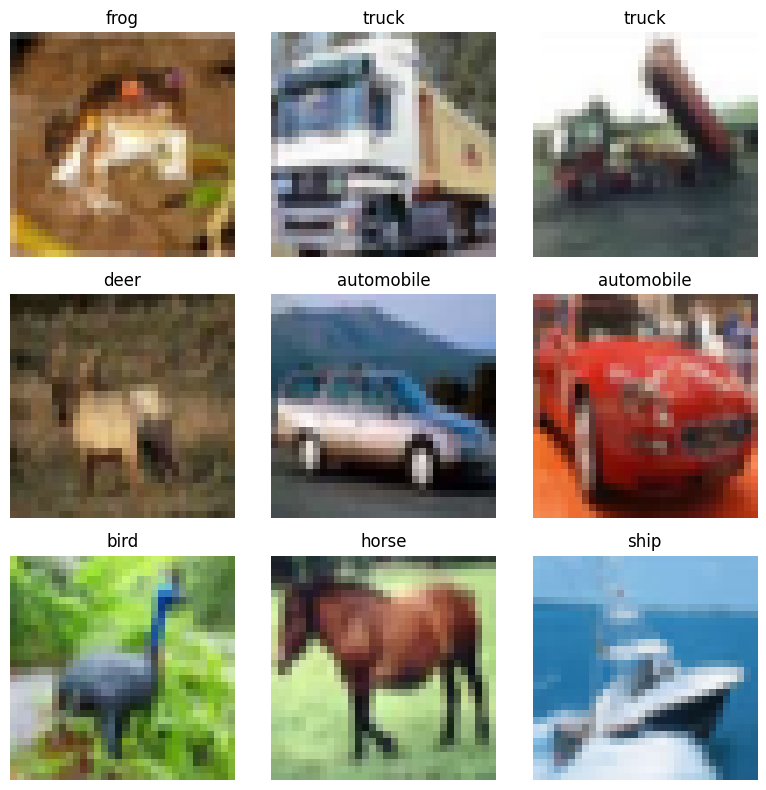

In [4]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(class_names[y_train_full[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Schritt 7: Normalisierung + Validation Split

In [5]:
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=5000, random_state=42
)

# Hyperparameter festlegen

In [6]:
input_patience = 3
input_epochs = 50

# Schritt 8: Basismodell (ohne Dropout, ohne BatchNorm)
## Basismodell

Ein einfaches CNN ohne Dropout und ohne BatchNormalization.

In [7]:
def build_base_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Schritt 9: Kompilieren + Early Stopping

In [8]:
def make_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=input_patience,
        restore_best_weights=True
    )

In [9]:
model_base = build_base_model()

model_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Schritt 10: Training Basismodell

In [10]:
history_base = model_base.fit(
    X_train, y_train,
    epochs=input_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    batch_size=32,
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 107ms/step - accuracy: 0.4636 - loss: 1.4848 - val_accuracy: 0.5826 - val_loss: 1.1737
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 105ms/step - accuracy: 0.6314 - loss: 1.0482 - val_accuracy: 0.6466 - val_loss: 1.0002
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 201s 105ms/step - accuracy: 0.6979 - loss: 0.8638 - val_accuracy: 0.6854 - val_loss: 0.9010
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 105ms/step - accuracy: 0.7384 - loss: 0.7495 - val_accuracy: 0.7188 - val_loss: 0.7996
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 204s 107ms/step - accuracy: 0.7666 - loss: 0.6618 - val_accuracy: 0.7316 - val_loss: 0.7728
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 107ms/step - accuracy: 0.7931 - loss: 0.5896 - val_accuracy: 0.7404 - val_loss: 0.7796
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 106ms/step - accuracy: 0.8146 - loss: 0.5242 - val_accuracy: 0.7442 - val_loss: 0.7632
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 206s 109ms/step - ac

# Schritt 11: Dropout-Modell
## Modell mit Dropout

Dropout reduziert Overfitting, indem zufällig Neuronen deaktiviert werden.

In [11]:
def build_dropout_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [12]:
model_dropout = build_dropout_model()

model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=input_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    batch_size=32,
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 159s 111ms/step - accuracy: 0.4236 - loss: 1.5763 - val_accuracy: 0.5412 - val_loss: 1.2487
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 109ms/step - accuracy: 0.5683 - loss: 1.2123 - val_accuracy: 0.6242 - val_loss: 1.0618
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 152s 108ms/step - accuracy: 0.6272 - loss: 1.0551 - val_accuracy: 0.6722 - val_loss: 0.9132
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 152s 108ms/step - accuracy: 0.6666 - loss: 0.9500 - val_accuracy: 0.7014 - val_loss: 0.8287
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 108ms/step - accuracy: 0.6888 - loss: 0.8819 - val_accuracy: 0.7146 - val_loss: 0.7999
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 204s 109ms/step - accuracy: 0.7097 - loss: 0.8311 - val_accuracy: 0.7304 - val_loss: 0.7542
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 109ms/step - accuracy: 0.7221 - loss: 0.7890 - val_accuracy: 0.7364 - val_loss: 0.7285
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 207s 113ms/step - ac

# Schritt 12: BatchNorm-Modell
## Modell mit BatchNormalization

BatchNormalization stabilisiert und beschleunigt das Training.

In [13]:
def build_bn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.Conv2D(32, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.Conv2D(64, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [14]:
model_bn = build_bn_model()

model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = model_bn.fit(
    X_train, y_train,
    epochs=input_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    batch_size=32,
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 203s 141ms/step - accuracy: 0.5408 - loss: 1.2812 - val_accuracy: 0.6096 - val_loss: 1.0873
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 193s 137ms/step - accuracy: 0.6934 - loss: 0.8773 - val_accuracy: 0.6746 - val_loss: 0.9407
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 194s 138ms/step - accuracy: 0.7440 - loss: 0.7336 - val_accuracy: 0.7086 - val_loss: 0.8253
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 194s 138ms/step - accuracy: 0.7749 - loss: 0.6428 - val_accuracy: 0.7080 - val_loss: 0.8563
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 200s 136ms/step - accuracy: 0.7992 - loss: 0.5741 - val_accuracy: 0.6940 - val_loss: 0.8776
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 193s 137ms/step - accuracy: 0.8192 - loss: 0.5197 - val_accuracy: 0.6960 - val_loss: 0.8678


# Schritt 13: Lernkurven vergleichen

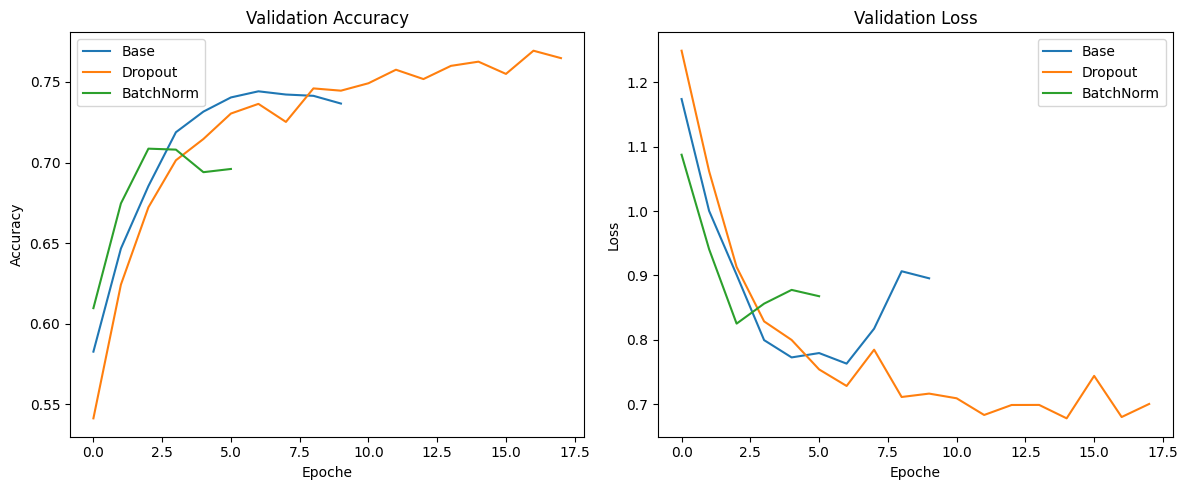

In [15]:
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_base.history['val_accuracy'], label='Base')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_bn.history['val_accuracy'], label='BatchNorm')
plt.title("Validation Accuracy")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()

# Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_base.history['val_loss'], label='Base')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_bn.history['val_loss'], label='BatchNorm')
plt.title("Validation Loss")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 14: Test-Accuracy vergleichen

In [16]:
acc_base = model_base.evaluate(X_test, y_test, verbose=0)[1]
acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)[1]
acc_bn = model_bn.evaluate(X_test, y_test, verbose=0)[1]

print("Base:", acc_base)
print("Dropout:", acc_dropout)
print("BatchNorm:", acc_bn)

Base: 0.7346000075340271
Dropout: 0.76419997215271
BatchNorm: 0.7117000222206116


# Schritt 15: Konfusionsmatrix

In [17]:
models = {
    "Base": model_base,
    "Dropout": model_dropout,
    "BatchNorm": model_bn
}

accuracies = {
    "Base": acc_base,
    "Dropout": acc_dropout,
    "BatchNorm": acc_bn
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Bestes Modell:", best_model_name)

Bestes Modell: Dropout


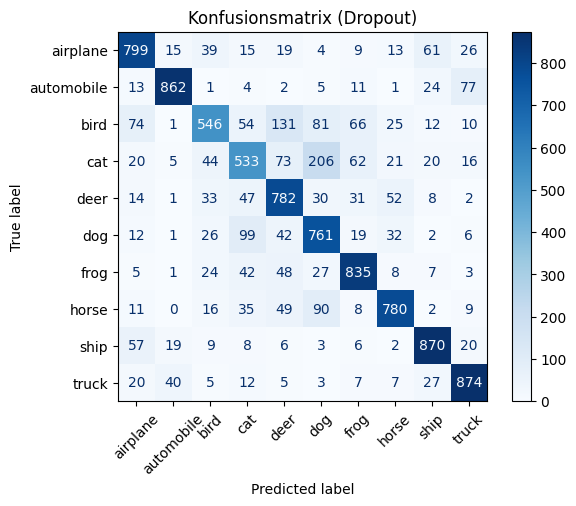

In [18]:
y_pred = best_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title(f"Konfusionsmatrix ({best_model_name})")
plt.show()

# Schritt 16: Interpretation (wichtig!)
## Interpretation

Wichtiger technischer Hinweis:
Für jedes Modell muss ein eigener EarlyStopping-Callback verwendet werden.
Wird derselbe Callback mehrfach wiederverwendet, können spätere Modelle zu früh stoppen.

### Beobachtungen

- Das Basismodell liefert eine sinnvolle Referenz
- Dropout kann Overfitting reduzieren, darf aber nicht zu stark gewählt werden
- BatchNormalization verbessert häufig die Trainingsstabilität und beschleunigt die Konvergenz

### Typische Verwechslungen in CIFAR-10

- cat ↔ dog
- deer ↔ horse
- automobile ↔ truck

## Fazit

Dropout und BatchNormalization sind hilfreiche Bausteine für CNNs,
müssen aber sauber implementiert und fair verglichen werden.